In [1]:
import torch
import numpy as np
from transformers import AutoTokenizer, Gemma3ForConditionalGeneration

model_id = "INSAIT-Institute/BgGPT-Gemma-3-4B-IT"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id, device_map="auto"
).eval()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

In [2]:
# extract full input embeddings weight matrix so we can sample both database vectors and distinct out-of-set query vectors
full_embeddings = model.model.get_input_embeddings().weight.detach().cpu().float().numpy()

np.random.seed(42)
# Partition the vocabulary: 10,000 vectors for our searchable indexing database, and 256 completely separate vectors for queries
all_sampled_indices = np.random.choice(full_embeddings.shape[0], size=101_000, replace=False)

embeddings = full_embeddings[all_sampled_indices[:100_000]]
query_embeddings = full_embeddings[all_sampled_indices[100_000:]]

print("Database Embeddings Shape:", embeddings.shape)
print("Out-of-set Query Embeddings Shape:", query_embeddings.shape)

Database Embeddings Shape: (100000, 2560)
Out-of-set Query Embeddings Shape: (1000, 2560)


In [3]:
E = embeddings/np.linalg.norm(embeddings, axis=1, keepdims=True)
queries = query_embeddings / np.linalg.norm(query_embeddings, axis=1, keepdims=True)

In [4]:
from scipy.stats import ortho_group

def create_rotation_matrix(dim):
    return ortho_group.rvs(dim)
# generate a random 32x32 orthogonal matrix
def random_rotation(matrix, R_mat=None):
    if R_mat is None:
        R_mat = create_rotation_matrix(matrix.shape[1])
    return matrix @ R_mat

In [5]:
R = random_rotation(E)
R.shape

(100000, 2560)

In [6]:
def sample_random_matrix(dim, seed=42):
    """Create a scaled random orthogonal matrix S with entry std = 1.0."""
    rng = np.random.default_rng(seed)
    G = rng.normal(size=(dim, dim)).astype(np.float32)
    q, r = np.linalg.qr(G)
    d_diag = np.diagonal(r)
    ph = d_diag / np.abs(d_diag)
    W = q * ph
    # Bake in sqrt(d) so std is 1.0, matching Definition 1
    return (np.sqrt(dim) * W).astype(np.float32)

In [7]:
from scipy.stats import norm

def compute_lloyd_max_thresholds(dim, bits, n_iter: int = 100):
    """Compute Lloyd-Max thresholds and levels for N(0, sigma) via iteration."""

    sigma = 1.0 / np.sqrt(dim)
    n_levels = 2 ** bits

    # Initialise thresholds from uniform quantile spacing
    probs = np.linspace(0, 1, n_levels + 1)
    thresholds = norm.ppf(probs[1:-1], scale=sigma)  # shape: (n_levels - 1,)

    def _conditional_mean(a, b):
        """E[X | a < X < b] for X ~ N(0, sigma)."""
        fa = norm.pdf(a, scale=sigma)
        fb = norm.pdf(b, scale=sigma)
        prob = norm.cdf(b, scale=sigma) - norm.cdf(a, scale=sigma)
        return sigma**2 * (fa - fb) / prob

    for _ in range(n_iter):
        # Boundaries (±inf for outermost bins)
        bounds = np.concatenate([[-np.inf], thresholds, [np.inf]])
        # Update levels: conditional mean of each bin
        levels = np.array([_conditional_mean(bounds[i], bounds[i + 1])
                            for i in range(n_levels)])
        # Update thresholds: midpoint between adjacent levels
        new_thresholds = (levels[:-1] + levels[1:]) / 2.0
        if np.max(np.abs(new_thresholds - thresholds)) < 1e-12:
            break
        thresholds = new_thresholds

    return thresholds, levels


class TurboQuantMSE:
    """
    TurboQuant quantizer optimized for MSE.

    Steps:
      quantize:   x -> rotate (x @ R) -> Lloyd-Max quantize -> integer indices
      dequantize: indices -> Lloyd-Max levels -> un-rotate (@ R.T)

    The quantization levels are precomputed for N(0, 1/sqrt(dim)), which is
    exactly the distribution of each dimension after random rotation of
    unit-norm vectors.
    """

    def __init__(self, dim: int, bits: int = 4, rotation_matrix=None):
        self.dim = dim
        self.bits = bits
        self.R = rotation_matrix if rotation_matrix is not None else create_rotation_matrix(dim)
        self.thresholds, self.levels = compute_lloyd_max_thresholds(self.dim, self.bits, n_iter=100)

    def quantize(self, x: np.ndarray) -> np.ndarray:
        """
        Rotate x and quantize each value to the nearest Lloyd-Max level.

        Parameters
        ----------
        x : ndarray, shape (..., dim)

        Returns
        -------
        indices : ndarray of uint8, shape (..., dim)
            Integer codes in [0, 2**bits).
        """
        rotated = x @ self.R
        indices = np.digitize(rotated, self.thresholds).astype(np.uint8)
        return indices

    def dequantize(self, indices: np.ndarray) -> np.ndarray:
        """
        Map integer codes back to level values and un-rotate.

        Parameters
        ----------
        indices : ndarray of uint8, shape (..., dim)

        Returns
        -------
        x_hat : ndarray, shape (..., dim)
            Reconstructed vectors in the original (un-rotated) space.
        """
        reconstructed = self.levels[indices]
        return reconstructed @ self.R.T

class TurboQuantIP:
    """
    TurboQuant product quantizer that follows:
      Q_prod(x) = [Q_mse(x), Q_qj1(r), ||r||_2]
    where r = x - Q_mse^{-1}(Q_mse(x)).
    """

    def __init__(
        self,
        dim: int,
        bits: int = 3,
        rotation_matrix=None,
        jl_seed: int = 0,
    ):
        if bits < 2:
            raise ValueError("bits must be >= 2 (b-1 for MSE + 1 bit for QJ1).")

        self.dim = int(dim)
        self.bits = int(bits)
        self.eps = 1e-12

        # Reuse TurboQuantMSE internally with b-1 bits, per paper.
        self.base = TurboQuantMSE(dim=self.dim, bits=self.bits - 1, rotation_matrix=rotation_matrix)

        self.jl_matrix = sample_random_matrix(self.dim, seed=jl_seed).astype(np.float32)
        self.scale = np.sqrt(np.pi / 2.0) / self.dim


    def _qjl_inverse(self, residual_sign: np.ndarray) -> np.ndarray:
        """Map sign codes back via scaled orthogonal projection: c * Pi * z."""
        sign = np.asarray(residual_sign, dtype=np.float32)
        if sign.ndim == 1:
            sign = sign[None, :]

        z = 2.0 * sign - 1.0  # {0,1} -> {-1,+1}
        # In paper notation: Q_qj1^{-1}(z) = c * Pi^T * z
        return (self.scale * (z @ self.jl_matrix.T)).astype(np.float32)

    def quantize(self, x: np.ndarray):
        """Return packed representation: base codes, QJL signs, and ||r||_2."""
        x = np.asarray(x, dtype=np.float32)
        if x.ndim == 1:
            x = x[None, :]
        if x.shape[1] != self.dim:
            raise ValueError("Input dimension does not match quantizer dimension.")

        base_codes = self.base.quantize(x)
        base_hat = self.base.dequantize(base_codes).astype(np.float32)

        residual = x - base_hat
        residual_norm = np.linalg.norm(residual, axis=1).astype(np.float32)

        # QJL is applied to residual direction; norm is stored separately.
        residual_dir = residual / np.maximum(residual_norm[:, None], self.eps)
        projected = residual_dir @ self.jl_matrix
        residual_sign = (projected >= 0).astype(np.uint8)

        return {
            "base_codes": base_codes,
            "residual_sign": residual_sign,
            "residual_norm": residual_norm,
        }

    def dequantize(self, packed) -> np.ndarray:
        """Reconstruct x_hat = x_mse + ||r||_2 * qjl^{-1}(qjl(r))."""
        x_hat = self.base.dequantize(packed['base_codes']).astype(np.float32)

        residual_norm = np.asarray(packed["residual_norm"], dtype=np.float32)
        qjl_residual = self._qjl_inverse(packed["residual_sign"])
        return x_hat + residual_norm[:, None] * qjl_residual


In [ ]:
def calculate_metrics(original_vectors, quantizer, queries, return_details=False):
    """
    Measure distortion of inner products after quantization, including bias and Recall@k.

    If quantizer provides estimate_inner_products(...), use that estimator.
    Otherwise, fall back to quantize -> dequantize -> dot products.
    """
    V = np.asarray(original_vectors, dtype=np.float32)
    Q = np.asarray(queries, dtype=np.float32)

    if Q.ndim == 1:
        Q = Q[None, :]

    if V.ndim != 2 or Q.ndim != 2:
        raise ValueError("original_vectors and queries must be 2D (or 1D query).")
    if V.shape[1] != Q.shape[1]:
        raise ValueError("Dimension mismatch between vectors and queries.")

    true_ip = Q @ V.T

    packed = quantizer.quantize(V)
    V_hat = quantizer.dequantize(packed).astype(np.float32)
    approx_ip = Q @ V_hat.T

    err = approx_ip - true_ip
    abs_err = np.abs(err)

    bias = float(err.mean())
    mae = float(abs_err.mean())
    max_abs_error = float(abs_err.max())
    mean_true_abs_ip = float(np.mean(np.abs(true_ip)))
    relative_mae = float(mae / (mean_true_abs_ip + 1e-12))

    # Evaluate Recall@k: check if true closest neighbour (arg max true_ip) is in top-k of approx_ip
    true_closest = np.argmax(true_ip, axis=1) # shape: (n_queries,)
    rankings_approx = np.argsort(-approx_ip, axis=1) # shape: (n_queries, n_vectors), sorted highest to lowest

    recall_at_1 = float(np.mean(rankings_approx[:, :1].squeeze() == true_closest))
    # rankings_approx[:, :2] matches shape (n_queries, 2). Check if true_closest is in that slice.
    recall_at_2 = float(np.mean([true_closest[i] in rankings_approx[i, :2] for i in range(Q.shape[0])]))
    recall_at_10 = float(np.mean([true_closest[i] in rankings_approx[i, :10] for i in range(Q.shape[0])]))

    metrics = {
        "bias": bias,
        "mae": mae,
        "max_abs_error": max_abs_error,
        "mean_true_abs_ip": mean_true_abs_ip,
        "relative_mae": relative_mae,
        "recall_1": recall_at_1,
        "recall_2": recall_at_2,
        "recall_10": recall_at_10,
        "n_queries": int(Q.shape[0]),
        "n_vectors": int(V.shape[0]),
    }

    if return_details:
        return metrics, {
            "error": err,
            "abs_error": abs_err,
            "true_ip": true_ip,
            "approx_ip": approx_ip,
        }

    return metrics

In [9]:


# Build quantizers and smoke test
quantizer = TurboQuantMSE(dim=E.shape[1], bits=4, rotation_matrix=None)
metrics = calculate_metrics(E, quantizer, queries)
display(metrics)

ip_quantizer = TurboQuantIP(dim=E.shape[1], bits=4, rotation_matrix=quantizer.R)
ip_metrics = calculate_metrics(E, ip_quantizer, queries)
ip_metrics

{'bias': -0.00028289214242249727,
 'mae': 0.0015641687205061316,
 'rmse': 0.001965506235137582,
 'max_abs_error': 0.019801318645477295,
 'mean_true_abs_ip': 0.03234006464481354,
 'relative_mae': 0.048366283049734574,
 'recall_1': 0.965,
 'recall_2': 0.98,
 'recall_10': 0.982,
 'n_queries': 1000,
 'n_vectors': 100000}

{'bias': 1.4861874433336197e-06,
 'mae': 0.0022127937991172075,
 'rmse': 0.0027738676872104406,
 'max_abs_error': 0.016188697889447212,
 'mean_true_abs_ip': 0.03234006464481354,
 'relative_mae': 0.0684226770524918,
 'recall_1': 0.95,
 'recall_2': 0.977,
 'recall_10': 0.982,
 'n_queries': 1000,
 'n_vectors': 100000}

In [15]:
# Build quantizers and smoke test
quantizer = TurboQuantMSE(dim=E.shape[1], bits=3, rotation_matrix=None)
metrics_3bit = calculate_metrics(E, quantizer, queries)

ip_quantizer = TurboQuantIP(dim=E.shape[1], bits=3, rotation_matrix=quantizer.R)
ip_metrics = calculate_metrics(E, ip_quantizer, queries)



print("Comparison of Inner Product Distortion Metrics (including Recall for 3 bits):")
print(f"3-bit MSE (Baseline):  Bias: {metrics_3bit['bias']:+.6f}, MAE: {metrics_3bit['mae']:.6f}, RMSE: {metrics_3bit['rmse']:.6f}, R@1: {metrics_3bit['recall_1']:.4f}, R@2: {metrics_3bit['recall_2']:.4f}")
print(f"IP (2-bit + 1-bit QJL): Bias: {ip_metrics['bias']:+.6f},  MAE: {ip_metrics['mae']:.6f}, RMSE: {ip_metrics['rmse']:.6f}, R@1: {ip_metrics['recall_1']:.4f}, R@2: {ip_metrics['recall_2']:.4f}")


Comparison of Inner Product Distortion Metrics (including Recall for 3 bits):
3-bit MSE (Baseline):  Bias: -0.001032, MAE: 0.003113, RMSE: 0.003971, R@1: 0.9310, R@2: 0.9740
IP (2-bit + 1-bit QJL): Bias: +0.000001,  MAE: 0.004081, RMSE: 0.005116, R@1: 0.9200, R@2: 0.9640


In [18]:
import pandas as pd
def compare(bits):
    quantizer = TurboQuantMSE(dim=E.shape[1], bits=bits, rotation_matrix=None)
    metrics_mse = calculate_metrics(E, quantizer, queries)

    ip_quantizer = TurboQuantIP(dim=E.shape[1], bits=bits, rotation_matrix=quantizer.R)
    metrics_ip = calculate_metrics(E, ip_quantizer, queries)

    return pd.DataFrame([metrics_mse, metrics_ip], index=[f"{bits}-bit MSE", f"IP ({bits-1}-bit + 1-bit QJL)"])

In [23]:
compare(2)

,bias,mae,rmse,max_abs_error,mean_true_abs_ip,relative_mae,recall_1,recall_2,recall_10,n_queries,n_vectors
2-bit MSE,-0.003484,0.006397,0.008518,0.140994,0.03234,0.197814,0.904,0.958,0.979,1000,100000
IP (1-bit + 1-bit QJL),0.000035,0.007180,0.008999,0.050446,0.03234,0.222016,0.883,0.956,0.980,1000,100000


In [24]:
compare(3)

,bias,mae,rmse,max_abs_error,mean_true_abs_ip,relative_mae,recall_1,recall_2,recall_10,n_queries,n_vectors
3-bit MSE,-0.001024,0.003111,0.003970,0.048291,0.03234,0.096200,0.937,0.976,0.984,1000,100000
IP (2-bit + 1-bit QJL),0.000002,0.004081,0.005116,0.029501,0.03234,0.126197,0.923,0.964,0.980,1000,100000


In [25]:
compare(4)

,bias,mae,rmse,max_abs_error,mean_true_abs_ip,relative_mae,recall_1,recall_2,recall_10,n_queries,n_vectors
4-bit MSE,-0.000293,0.001575,0.002000,0.024927,0.03234,0.048700,0.955,0.979,0.982,1000,100000
IP (3-bit + 1-bit QJL),0.000002,0.002215,0.002777,0.016803,0.03234,0.068505,0.944,0.977,0.981,1000,100000


In [17]:
# Compare 3-bit MSE baseline, 4-bit MSE baseline, and 3-bit base + 1-bit QJL (4-bit total)
quantizer_3bit = TurboQuantMSE(dim=E.shape[1], bits=3, rotation_matrix=quantizer.R)
ip_quantizer_3bit = TurboQuantIP(dim=E.shape[1], bits=3, rotation_matrix=quantizer.R)

metrics_3bit = calculate_metrics(E, quantizer_3bit, queries)
metrics_ip_3bit = calculate_metrics(E, ip_quantizer_3bit, queries)

print("Comparison of Inner Product Distortion Metrics (including Recall):")
print(f"4-bit MSE (Baseline):  Bias: {metrics_3bit['bias']:+.6f}, MAE: {metrics_3bit['mae']:.6f}, RMSE: {metrics_3bit['rmse']:.6f}, R@1: {metrics_3bit['recall_1']:.4f}, R@2: {metrics_3bit['recall_2']:.4f}")
print(f"IP (3-bit + 1-bit QJL): Bias: {metrics_ip_3bit['bias']:+.6f},  MAE: {metrics_ip_3bit['mae']:.6f}, RMSE: {metrics_ip_3bit['rmse']:.6f}, R@1: {metrics_ip_3bit['recall_1']:.4f}, R@2: {metrics_ip_3bit['recall_2']:.4f}")


KeyboardInterrupt: 

In [11]:
# Compare 1-bit MSE baseline, 2-bit MSE baseline, and 1-bit base + 1-bit QJL (2-bit total)
quantizer_2bit = TurboQuantMSE(dim=E.shape[1], bits=2, rotation_matrix=quantizer.R)
ip_quantizer_2bit = TurboQuantIP(dim=E.shape[1], bits=2, rotation_matrix=quantizer.R)

metrics_2bit = calculate_metrics(E, quantizer_2bit, queries)
metrics_ip_2bit = calculate_metrics(E, ip_quantizer_2bit, queries)

print("Comparison of Inner Product Distortion Metrics for 2-bit Budget (including Recall):")
print(f"IP (1-bit + 1-bit QJL): Bias: {metrics_ip_2bit['bias']:+.6f}, MAE: {metrics_ip_2bit['mae']:.6f}, RMSE: {metrics_ip_2bit['rmse']:.6f}, R@1: {metrics_ip_2bit['recall_1']:.4f}, R@2: {metrics_ip_2bit['recall_2']:.4f}")
print(f"2-bit MSE (Baseline):  Bias: {metrics_2bit['bias']:+.6f}, MAE: {metrics_2bit['mae']:.6f}, RMSE: {metrics_2bit['rmse']:.6f}, R@1: {metrics_2bit['recall_1']:.4f}, R@2: {metrics_2bit['recall_2']:.4f}")

Comparison of Inner Product Distortion Metrics for 2-bit Budget (including Recall):
IP (1-bit + 1-bit QJL): Bias: -0.000010, MAE: 0.007177, RMSE: 0.008995, R@1: 0.8910, R@2: 0.9540
2-bit MSE (Baseline):  Bias: -0.003457, MAE: 0.006375, RMSE: 0.008450, R@1: 0.9100, R@2: 0.9610


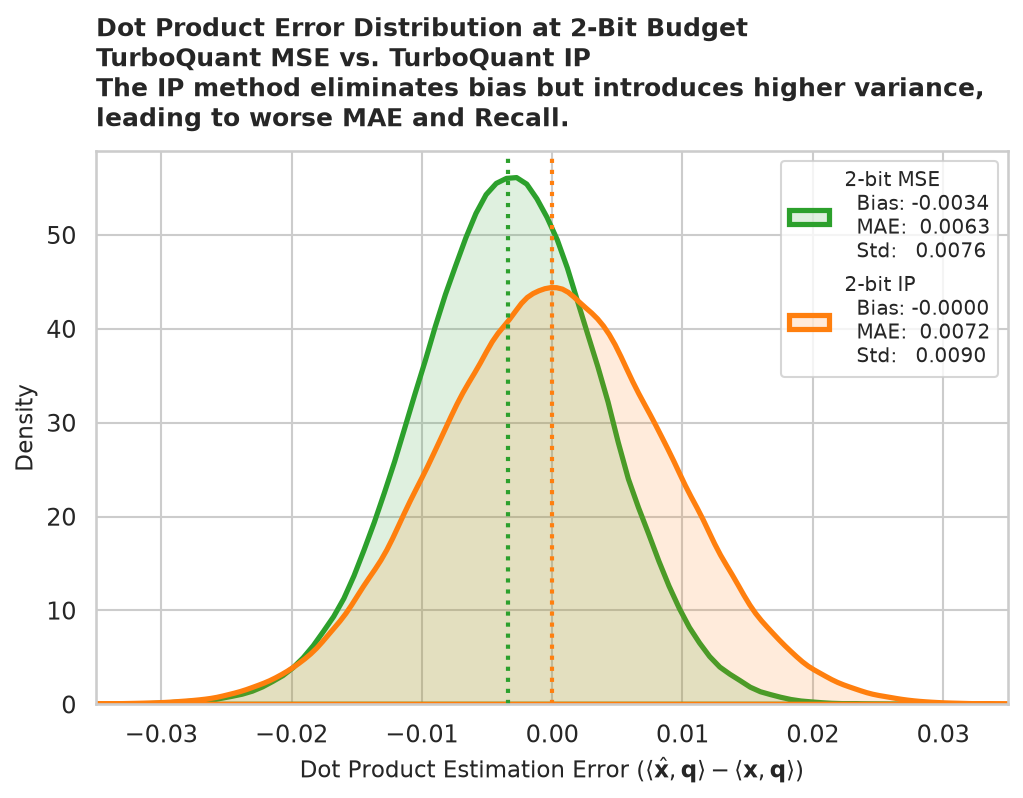

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set clean aesthetic style
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Subsample database vectors for fast metric computation (5,000 vectors x 1,000 queries = 5M pairs)
E_sub = E[:5000]

# Instantiate quantizers for 2-bit comparison (sharing base rotation matrix R)
quantizer_2b = TurboQuantMSE(dim=E.shape[1], bits=2, rotation_matrix=None)
ip_quantizer_2b = TurboQuantIP(dim=E.shape[1], bits=2, rotation_matrix=quantizer_2b.R)

# Compute error distributions
_, details_mse_2b = calculate_metrics(E_sub, quantizer_2b, queries, return_details=True)
_, details_ip_2b = calculate_metrics(E_sub, ip_quantizer_2b, queries, return_details=True)

err_mse = details_mse_2b["error"].ravel()
err_ip = details_ip_2b["error"].ravel()

mean_mse = float(np.mean(err_mse))
std_mse = float(np.std(err_mse))
mae_mse = float(np.mean(np.abs(err_mse)))

mean_ip = float(np.mean(err_ip))
std_ip = float(np.std(err_ip))
mae_ip = float(np.mean(np.abs(err_ip)))

# Subsample points for smooth plotting
rng = np.random.default_rng(42)
plot_mse = rng.choice(err_mse, size=min(300_000, len(err_mse)), replace=False)
plot_ip = rng.choice(err_ip, size=min(300_000, len(err_ip)), replace=False)

# Square aspect ratio
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=150)

# KDE / Hist density
sns.kdeplot(plot_mse, ax=ax, label=f"2-bit MSE\n  Bias: {mean_mse:+.4f}\n  MAE:  {mae_mse:.4f}\n  Std:   {std_mse:.4f}", 
            color="#2ca02c", linewidth=2.5, fill=True, alpha=0.15)
sns.kdeplot(plot_ip, ax=ax, label=f"2-bit IP \n  Bias: {mean_ip:+.4f}\n  MAE:  {mae_ip:.4f}\n  Std:   {std_ip:.4f}", 
            color="#ff7f0e", linewidth=2.5, fill=True, alpha=0.15)

# Means
ax.axvline(mean_mse, color="#2ca02c", linestyle=":", linewidth=2)
ax.axvline(mean_ip, color="#ff7f0e", linestyle=":", linewidth=2)

ax.set_title("Dot Product Error Distribution at 2-Bit Budget\nTurboQuant MSE vs. TurboQuant IP\nThe IP method eliminates bias but introduces higher variance,\nleading to worse MAE and Recall.", 
             fontsize=12, fontweight="bold", pad=12, loc='left')
ax.set_xlabel(r"Dot Product Estimation Error ($\langle \hat{\mathbf{x}}, \mathbf{q} \rangle - \langle \mathbf{x}, \mathbf{q} \rangle$)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_xlim(-0.035, 0.035)
ax.legend(loc="upper right", frameon=True, fontsize=9.5)

plt.tight_layout()
plt.savefig("../images/turboquant-2bit-error-dist.png", dpi=200, bbox_inches="tight")
plt.show()